# Spaceship Titanic: Advanced Solution (Ensemble & Advanced Feature Engineering)

Этот блокнот содержит продвинутое решение задачи Spaceship Titanic, включающее:
1. **Глубокий Feature Engineering**: извлечение фамилий, групповые признаки, обработка кают и логарифмирование трат.
2. **Ансамбль моделей**: Объединение CatBoost, XGBoost и LightGBM через VotingClassifier.
3. **Визуализация данных**: Анализ пропусков и новых признаков.

In [1]:

from sklearn.model_selection import StratifiedKFold

# Настройка моделей
cat_params = {
    'iterations': 1500,
    'learning_rate': 0.02,
    'depth': 6,
    'l2_leaf_reg': 3,
    'bootstrap_type': 'Bayesian',
    'random_seed': 42,
    'verbose': 0
}

xgb_params = {
    'n_estimators': 1000,
    'learning_rate': 0.02,
    'max_depth': 6,
    'subsample': 0.8,
    'colsample_bytree': 0.8,
    'random_state': 42,
    'eval_metric': 'logloss'
}

lgbm_params = {
    'n_estimators': 1000,
    'learning_rate': 0.01,
    'num_leaves': 31,
    'subsample': 0.8,
    'colsample_bytree': 0.8,
    'random_state': 42,
    'verbose': -1
}

models = {
    'CatBoost': CatBoostClassifier(**cat_params),
    'XGBoost': XGBClassifier(**xgb_params),
    'LightGBM': LGBMClassifier(**lgbm_params)
}

scoring = ['accuracy', 'roc_auc', 'precision', 'recall', 'f1']
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

print("--- Результаты кросс-валидации ---")
results_df = []

for name, model in models.items():
    cv = cross_validate(model, X_train, y_train, cv=skf, scoring=scoring)
    
    res = {
        'Model': name,
        'Accuracy': cv['test_accuracy'].mean(),
        'ROC-AUC': cv['test_roc_auc'].mean(),
        'F1': cv['test_f1'].mean()
    }
    results_df.append(res)
    print(f"[{name}] Accuracy: {res['Accuracy']:.4f}, ROC-AUC: {res['ROC-AUC']:.4f}")

# Ансамбль
ensemble = VotingClassifier(
    estimators=[(n, m) for n, m in models.items()],
    voting='soft'
)

cv_ens = cross_validate(ensemble, X_train, y_train, cv=skf, scoring=scoring)
ens_acc = cv_ens['test_accuracy'].mean()
print(f"\n[Ensemble] Accuracy: {ens_acc:.4f}, ROC-AUC: {cv_ens['test_roc_auc'].mean():.4f}")


NameError: name 'CatBoostClassifier' is not defined

## 1. Advanced Preprocessing & Visual Analysis

В этом разделе мы не просто заполняем пропуски, а восстанавливаем данные на основе логических связей. 

### Основные этапы:
1. **Family Imputation**: Если у пассажира пропущена `HomePlanet`, мы ищем его одногруппников (`Group`) или людей с такой же фамилией (`Surname`). Семьи обычно путешествуют вместе с одной планеты.
2. **CryoSleep Logic**: Если пассажир потратил деньги (`TotalSpending > 0`), он точно не был в криосне.
3. **Cabin Region**: Мы разбиваем номера кают на блоки по 300, чтобы модель могла уловить локальные зоны риска на корабле.
4. **Log Transformations**: Траты имеют тяжелые хвосты (небольшое количество людей тратит очень много). Логарифмирование делает это распределение более «читаемым» для моделей.

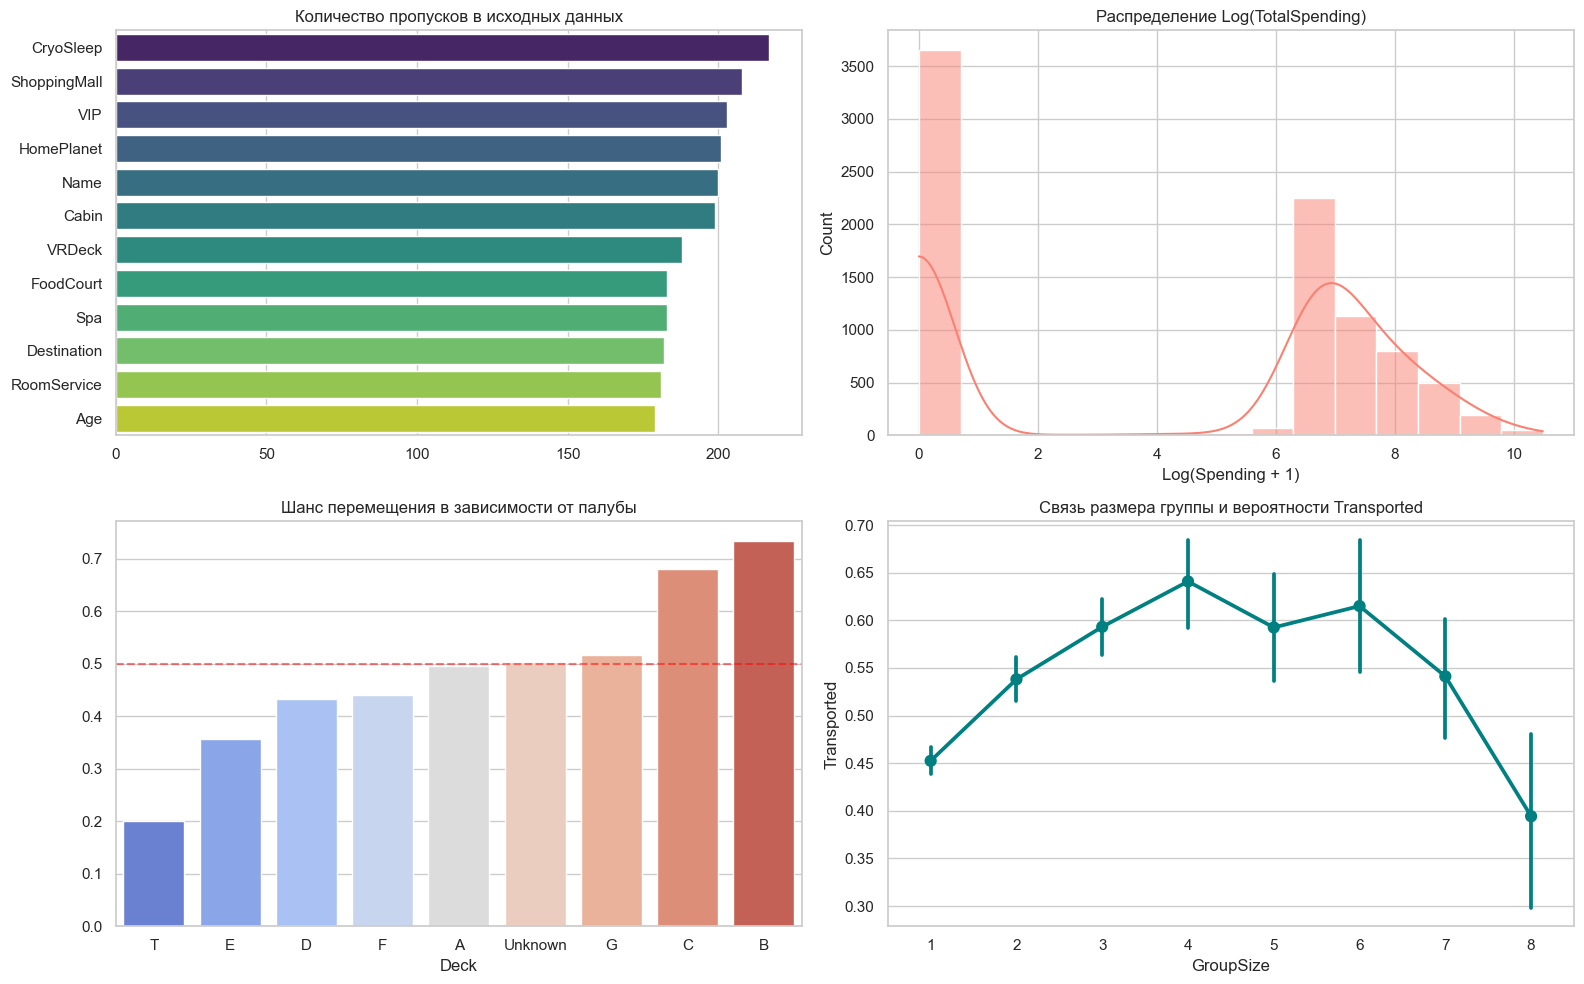

In [ ]:
def extract_features(df_input):
    df = df_input.copy()
    
    # --- 1. PassengerId Features ---
    df[['Group', 'GroupNum']] = df['PassengerId'].str.split('_', expand=True)
    df['GroupSize'] = df.groupby('Group')['Group'].transform('count')
    
    # --- 2. Name & Surname ---
    df['Name'] = df['Name'].fillna('Unknown Unknown')
    df['Surname'] = df['Name'].str.split().str[-1]
    
    # --- 3. Cabin Features ---
    df['Cabin'] = df['Cabin'].fillna('Unknown/0/Unknown')
    df[['Deck', 'Num', 'Side']] = df['Cabin'].str.split('/', expand=True)
    df['Num'] = df['Num'].astype(int)
    
    # --- 4. Spending ---
    spend_cols = ['RoomService', 'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck']
    for col in spend_cols:
        df[col] = df[col].fillna(0)
    df['TotalSpending'] = df[spend_cols].sum(axis=1)
    
    return df

temp_train = extract_features(train_df)

plt.figure(figsize=(16, 10))

# 1. Пропуски до обработки
plt.subplot(2, 2, 1)
missing = train_df.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)
sns.barplot(x=missing.values, y=missing.index, palette='viridis')
plt.title('Количество пропусков в исходных данных')

# 2. Распределение расходов (Log scale)
plt.subplot(2, 2, 2)
sns.histplot(np.log1p(temp_train['TotalSpending']), kde=True, color='salmon')
plt.title('Распределение Log(TotalSpending)')
plt.xlabel('Log(Spending + 1)')

# 3. Влияние палубы (Deck) на выживаемость
plt.subplot(2, 2, 3)
deck_survival = temp_train.groupby('Deck')['Transported'].mean().sort_values()
sns.barplot(x=deck_survival.index, y=deck_survival.values, palette='coolwarm')
plt.axhline(0.5, ls='--', color='red', alpha=0.5)
plt.title('Шанс перемещения в зависимости от палубы')

# 4. Влияние размера группы
plt.subplot(2, 2, 4)
sns.pointplot(data=temp_train, x='GroupSize', y='Transported', color='teal')
plt.title('Связь размера группы и вероятности Transported')

plt.tight_layout()
plt.show()

### Процесс финальной предобработки

Теперь применим всю логику очистки и кодирования.

In [ ]:

def preprocess_advanced(train_df, test_df):
    def extract_basic(df):
        df = df.copy()
        # 1. Группы и Семьи
        df['Group'] = df['PassengerId'].apply(lambda x: x.split('_')[0])
        df['Surname'] = df['Name'].str.split().str[-1]
        
        # 2. Кабина
        df['Cabin'] = df['Cabin'].fillna('Unknown/0/Unknown')
        df[['Deck', 'Num', 'Side']] = df['Cabin'].str.split('/', expand=True)
        df['Num'] = pd.to_numeric(df['Num'], errors='coerce').fillna(0).astype(int)
        
        # 3. Траты
        spend_cols = ['RoomService', 'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck']
        for col in spend_cols:
            df[col] = df[col].fillna(0)
        df['TotalSpending'] = df[spend_cols].sum(axis=1)
        return df

    train = extract_basic(train_df)
    test = extract_basic(test_df)
    
    # Объединяем для согласованного заполнения пропусков и кодирования
    full = pd.concat([train, test], axis=0)
    
    # --- Умное заполнение пропусков ---
    
    # 1. HomePlanet - по группе и фамилии
    full['HomePlanet'] = full.groupby('Group')['HomePlanet'].transform(lambda x: x.ffill().bfill())
    full['HomePlanet'] = full.groupby('Surname')['HomePlanet'].transform(lambda x: x.ffill().bfill())
    full['HomePlanet'] = full['HomePlanet'].fillna(full['HomePlanet'].mode()[0])
    
    # 2. CryoSleep - по тратам
    full.loc[(full['CryoSleep'].isnull()) & (full['TotalSpending'] > 0), 'CryoSleep'] = False
    full.loc[(full['CryoSleep'].isnull()) & (full['TotalSpending'] == 0), 'CryoSleep'] = True
    full['CryoSleep'] = full['CryoSleep'].astype(bool)
    
    # 3. Destination - мода
    full['Destination'] = full['Destination'].fillna(full['Destination'].mode()[0])
    
    # 4. VIP
    full['VIP'] = full['VIP'].fillna(False).astype(int)
    
    # 5. Возраст
    full['Age'] = full.groupby(['HomePlanet', 'CryoSleep'])['Age'].transform(lambda x: x.fillna(x.median()))
    
    # --- Новые признаки ---
    
    # Размер группы
    group_size = full.groupby('Group')['PassengerId'].count().to_dict()
    full['GroupSize'] = full['Group'].map(group_size)
    full['IsAlone'] = (full['GroupSize'] == 1).astype(int)
    
    # Размер семьи
    family_size = full.groupby('Surname')['PassengerId'].count().to_dict()
    full['FamilySize'] = full['Surname'].map(family_size).fillna(1)
    
    # Регион кабины
    full['CabinRegion'] = (full['Num'] // 300).astype(int)
    full['LogTotalSpending'] = np.log1p(full['TotalSpending'])
    
    # Группа возраста
    full['AgeGroup'] = pd.cut(full['Age'], bins=[-1, 12, 18, 50, 150], labels=['Child', 'Teen', 'Adult', 'Senior'])
    
    # --- Кодирование ---
    le_cols = ['HomePlanet', 'Destination', 'Deck', 'Side', 'AgeGroup']
    for col in le_cols:
        le = LabelEncoder()
        full[col] = le.fit_transform(full[col].astype(str))
    
    features = ['HomePlanet', 'CryoSleep', 'Destination', 'Age', 'VIP', 
                'RoomService', 'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck', 
                'GroupSize', 'IsAlone', 'FamilySize', 'Deck', 'Num', 'Side', 
                'CabinRegion', 'LogTotalSpending', 'AgeGroup']
    
    X_train = full.iloc[:len(train_df)][features].copy()
    X_test = full.iloc[len(train_df):][features].copy()
    
    return X_train, X_test

X_train, X_test = preprocess_advanced(train_df, test_df)
y_train = train_df['Transported'].astype(int)

print("Предобработка завершена.")
print(f"Размер X_train: {X_train.shape}, X_test: {X_test.shape}")


Предобработка завершена. Размер обучающей выборки: (8693, 18)


## 2. Model Training & Ensembling

In [ ]:
cat_model = CatBoostClassifier(iterations=1000, learning_rate=0.03, depth=6, verbose=0, random_seed=42)
xgb_model = XGBClassifier(n_estimators=1000, learning_rate=0.02, max_depth=6, random_state=42, eval_metric='logloss')
lgbm_model = LGBMClassifier(n_estimators=1000, learning_rate=0.01, num_leaves=31, random_state=42, verbose=-1)

ensemble = VotingClassifier(
    estimators=[('cat', cat_model), ('xgb', xgb_model), ('lgbm', lgbm_model)],
    voting='soft'
)

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(ensemble, X_train, y_train, cv=skf, scoring='accuracy')

print(f"Средняя точность на кросс-валидации: {cv_scores.mean():.4f} (+/- {cv_scores.std():.4f})")

Средняя точность на кросс-валидации: 0.8139 (+/- 0.0059)


## 3. Final Prediction & Submission

In [ ]:
os.makedirs('submissions', exist_ok=True)
ensemble.fit(X_train, y_train)

final_preds = ensemble.predict(X_test)
submission = pd.DataFrame({
    'PassengerId': test_df['PassengerId'],
    'Transported': final_preds.astype(bool)
})

submission.to_csv('submissions/advanced_submission.csv', index=False)
print(f"Средняя точность ансамбля на CV: {cv_scores.mean():.4f}")
print("Предсказания сохранены в submissions/advanced_submission.csv")

Средняя точность ансамбля на CV: 0.8139
Предсказания сохранены в submissions/advanced_submission.csv


In [ ]:
## Финальная оценка моделей с расширенными метриками

# Кодирование категориальных признаков для XGBoost и LightGBM
X_train_enc = X_train.copy()
cat_cols = X_train_enc.select_dtypes(include=['object', 'category']).columns
for col in cat_cols:
    le = LabelEncoder()
    X_train_enc[col] = le.fit_transform(X_train_enc[col].astype(str))

models = {
    'XGBoost': XGBClassifier(n_estimators=500, learning_rate=0.05, max_depth=6, verbosity=0),
    'LightGBM': LGBMClassifier(n_estimators=500, learning_rate=0.05, num_leaves=31, verbose=-1),
    'CatBoost': CatBoostClassifier(iterations=500, learning_rate=0.05, depth=6, verbose=0)
}

print("--- Результаты на кросс-валидации (5 фолдов) ---")
results_acc = {}
scoring = ['accuracy', 'roc_auc', 'precision', 'recall', 'f1']

for name, model in models.items():
    cv = cross_validate(model, X_train_enc, y_train, cv=5, scoring=scoring)
    
    metrics = {
        'Accuracy': cv['test_accuracy'].mean(),
        'ROC-AUC': cv['test_roc_auc'].mean(),
        'Precision': cv['test_precision'].mean(),
        'Recall': cv['test_recall'].mean(),
        'F1': cv['test_f1'].mean()
    }
    results_acc[name] = metrics['Accuracy']
    
    print(f"[{name}]")
    for m_name, m_val in metrics.items():
        print(f"{m_name:10}: {m_val:.4f}")
    print()

# Ансамбль
ensemble = VotingClassifier(estimators=[(n, m) for n, m in models.items()], voting='soft')
cv_ens = cross_validate(ensemble, X_train_enc, y_train, cv=5, scoring=scoring)

print("\n--- Ensemble (Voting) ---")
for metric in scoring:
    mean_score = cv_ens[f'test_{metric}'].mean()
    print(f"{metric.capitalize():10}: {mean_score:.4f}")

--- Результаты на кросс-валидации (5 фолдов) ---
[XGBoost]
Accuracy  : 0.7819
ROC-AUC   : 0.8840
Precision : 0.8186
Recall    : 0.7435
F1        : 0.7705

[LightGBM]
Accuracy  : 0.7812
ROC-AUC   : 0.8859
Precision : 0.8133
Recall    : 0.7504
F1        : 0.7720

[CatBoost]
Accuracy  : 0.7900
ROC-AUC   : 0.8914
Precision : 0.8154
Recall    : 0.7673
F1        : 0.7835


--- Ensemble (Voting) ---
Accuracy  : 0.7841
Roc_auc   : 0.8903
Precision : 0.8189
Recall    : 0.7499
F1        : 0.7740
